In [1]:
import os
import subprocess
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("result", exist_ok=True)
print("Environment ready!")

Environment ready!


In [7]:
print("Calling Makefile to compile C code...")

# Clean up previous build files (make clean)
subprocess.run(["make", "clean"], capture_output=True, text=True)

# Recompile (make)
compile_process = subprocess.run(["make"], capture_output=True, text=True)

if compile_process.returncode == 0:
    print("Compilation successful! Executable 'percolation_sim' is ready.")
else:
    print("Compilation failed, please check the error messages below:")
    print(compile_process.stderr)

Calling Makefile to compile C code...
Compilation successful! Executable 'percolation_sim' is ready.


In [8]:
import subprocess

print("Starting Hypergraph Percolation Simulation (this may take a few minutes)...\n")

process = subprocess.Popen(
    ["./percolation_sim"], 
    stdout=subprocess.PIPE, 
    stderr=subprocess.STDOUT, 
    text=True
)

is_progressing = False 

for line in process.stdout:
    text = line.strip() 
    if text:
        if text.startswith("Finished"):
            print(f"\r{text.ljust(60)}", end="", flush=True)
            is_progressing = True
        else:
            if is_progressing:
                print() 
                is_progressing = False
            print(text)

process.wait()

if process.returncode == 0:
    print("\nSimulation completed successfully!")
else:
    print("\nSimulation aborted or encountered an error, please check your C code.")

🚀 Starting Hypergraph Percolation Simulation (this may take a few minutes)...

--- Mode: Generating SYNTHETIC hypergraph data ---
Synthetic hypergraph generated: N=10000, Q=10000.
Hypergraph setup complete. Starting simulation loop.
Finished p_N=1.00, p_H=1.00                                 
Simulation finished. Data saved to result/ph_data.txt.

Simulation completed successfully!


Detected sweep variable: p_N (Node Percolation)
File saved: fig/ph_data.pdf


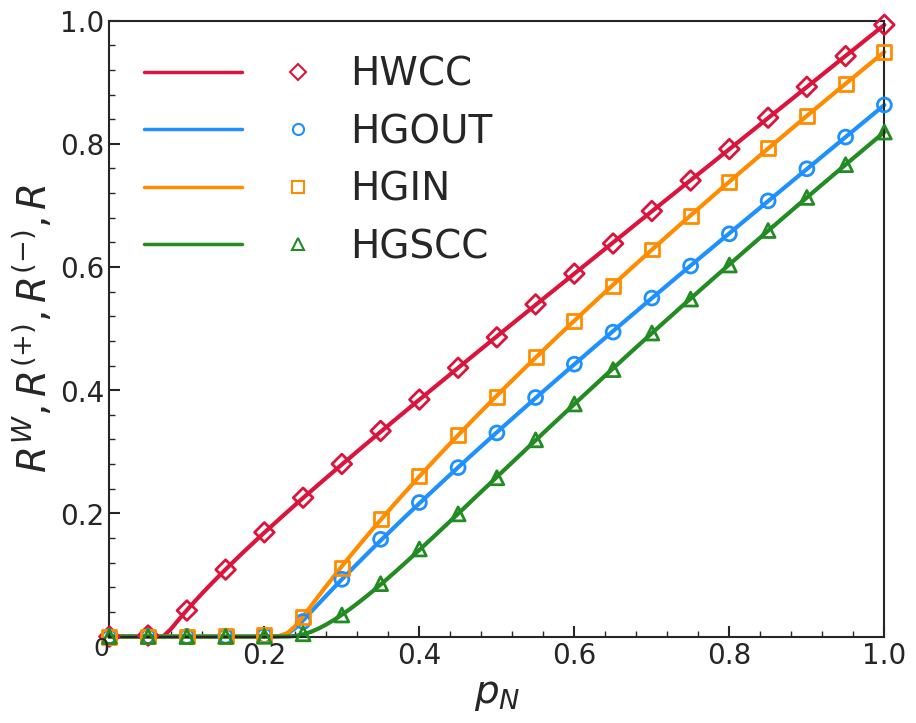

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import AutoMinorLocator
from matplotlib.lines import Line2D

plt.style.use('seaborn-v0_8-white')

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 18
plt.rcParams['axes.labelsize'] = 28
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams['legend.fontsize'] = 26
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['xtick.minor.width'] = 1.0
plt.rcParams['ytick.minor.width'] = 1.0

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white"
})

prename = 'ph_data'
filename = f'result/{prename}.txt'

try:
    df = pd.read_csv(filename, delimiter=',')
    
    if 'node_survival' in df.columns:
        df.rename(columns={'node_survival': 'p_N'}, inplace=True)
    if 'hyperedge_survival' in df.columns:
        df.rename(columns={'hyperedge_survival': 'p_H'}, inplace=True)

    if 'p_N' in df.columns and 'p_H' in df.columns:
        if df['p_N'].nunique() > 1 and df['p_H'].nunique() > 1:
            x_col = 'p_N'
            x_label = '$p=p_N=p_H$'
            print("Detected sweep variable: Joint Percolation (sweeping both p_N and p_H)")
        elif df['p_N'].nunique() > 1:
            x_col = 'p_N'
            x_label = '$p_N$'
            print("Detected sweep variable: p_N (Node Percolation)")
        else:
            x_col = 'p_H'
            x_label = '$p_H$'
            print("Detected sweep variable: p_H (Hyperedge Percolation)")
    elif 'p_N' in df.columns:
        x_col = 'p_N'
        x_label = '$p_N$'
        print("Detected sweep variable: p_N")
    else:
        # Fallback
        x_col = 'p_H'
        x_label = '$p_H$'
        print("Detected sweep variable: p_H")

    p_values_to_show = np.arange(0.0, 1.01, 0.05)
    df_scatter = df[df[x_col].round(2).isin(p_values_to_show.round(2))]

    fig, ax = plt.subplots(figsize=(10, 8))


    ax.plot(df[x_col], df['mp_hwcc'], color='crimson',     linestyle='-', linewidth=3, zorder=2, clip_on=False)
    ax.plot(df[x_col], df['mp_gout'], color='dodgerblue',  linestyle='-', linewidth=3, zorder=2, clip_on=False)
    ax.plot(df[x_col], df['mp_gin'],  color='darkorange',  linestyle='-', linewidth=3, zorder=2, clip_on=False)
    ax.plot(df[x_col], df['mp_gscc'], color='forestgreen', linestyle='-', linewidth=3, zorder=2, clip_on=False)

    ax.scatter(df_scatter[x_col], df_scatter['sim_hwcc'], facecolors='none', edgecolors='crimson',     marker='D', s=100, linewidth=2, zorder=3, clip_on=False)
    ax.scatter(df_scatter[x_col], df_scatter['sim_gout'], facecolors='none', edgecolors='dodgerblue',  marker='o', s=100, linewidth=2, zorder=3, clip_on=False)
    ax.scatter(df_scatter[x_col], df_scatter['sim_gin'],  facecolors='none', edgecolors='darkorange',  marker='s', s=100, linewidth=2, zorder=3, clip_on=False)
    ax.scatter(df_scatter[x_col], df_scatter['sim_gscc'], facecolors='none', edgecolors='forestgreen', marker='^', s=100, linewidth=2, zorder=3, clip_on=False)

    ax.set_xlabel(x_label, fontstyle='italic')
    ax.set_ylabel(r'$R^{W}\mathrm{,}\,R^{(+)}\mathrm{,}\,R^{(-)}\mathrm{,}\,R$')

    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0, 1.0)
    ax.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_xticklabels(['', '0.2', '0.4', '0.6', '0.8', '1.0'])
    ax.set_yticklabels(['', '0.2', '0.4', '0.6', '0.8', '1.0'])
    ax.text(0, 0, '0', horizontalalignment='right', verticalalignment='top', transform=ax.transAxes)

    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(5))
    ax.tick_params(which='major', direction='in', length=8)
    ax.tick_params(which='minor', direction='in', length=4)

    line_handles = [
        Line2D([0], [0], color='crimson',     lw=2.5),
        Line2D([0], [0], color='dodgerblue',  lw=2.5),
        Line2D([0], [0], color='darkorange',  lw=2.5),
        Line2D([0], [0], color='forestgreen', lw=2.5)
    ]
    marker_handles = [
        Line2D([0], [0], color='crimson',     marker='D', linestyle='None', markersize=8, markerfacecolor='none', markeredgewidth=1.5),
        Line2D([0], [0], color='dodgerblue',  marker='o', linestyle='None', markersize=8, markerfacecolor='none', markeredgewidth=1.5),
        Line2D([0], [0], color='darkorange',  marker='s', linestyle='None', markersize=8, markerfacecolor='none', markeredgewidth=1.5),
        Line2D([0], [0], color='forestgreen', marker='^', linestyle='None', markersize=8, markerfacecolor='none', markeredgewidth=1.5)
    ]

    handles = line_handles + marker_handles
    labels = ['', '', '', '', 'HWCC', 'HGOUT', 'HGIN', 'HGSCC']

    ax.legend(handles, labels,
              loc='best',
              ncol=2,
              frameon=False,
              fontsize=28,
              handlelength=2.5,
              handletextpad=0.1,
              columnspacing=0.1)

    output_filename = f'fig/{prename}.pdf'
    plt.savefig(output_filename, bbox_inches='tight', dpi=600)

    print(f"File saved: {output_filename}")

except Exception as e:
    print(f"Error: {e}")